## Data Analytics III

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score

In [5]:
df = pd.read_csv("Iris.csv")

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [6]:
df.shape

(150, 6)

## Separate Features & Target

In [7]:
X = df.iloc[:, :-1]
y = df.iloc[:, -1]

## Train-Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0
)

## Apply Naïve Bayes (Gaussian)

In [9]:
model = GaussianNB()
model.fit(X_train, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


## Make Predictions

In [10]:
y_pred = model.predict(X_test)

y_pred[:10]

array(['Iris-virginica', 'Iris-versicolor', 'Iris-setosa',
       'Iris-virginica', 'Iris-setosa', 'Iris-virginica', 'Iris-setosa',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-versicolor'],
      dtype='<U15')

## Confusion Matrix

In [11]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[16,  0,  0],
       [ 0, 18,  0],
       [ 0,  0, 11]])

## Compute TP, FP, TN, FN

In [12]:
TP = cm[0,0]
FP = cm[:,0].sum() - TP
FN = cm[0,:].sum() - TP
TN = cm.sum() - (TP + FP + FN)

TP, FP, TN, FN

(np.int64(16), np.int64(0), np.int64(29), np.int64(0))

## Performance Metrics

In [13]:
accuracy = accuracy_score(y_test, y_pred)
error_rate = 1 - accuracy
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')

accuracy, error_rate, precision, recall

(1.0, 0.0, 1.0, 1.0)

## Data Distribution

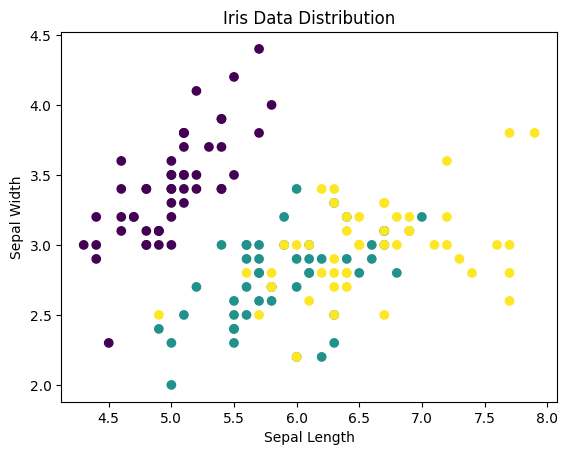

In [17]:
plt.scatter(df['SepalLengthCm'], df['SepalWidthCm'], c=pd.factorize(df['Species'])[0])
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")
plt.title("Iris Data Distribution")
plt.show()

## Confusion Matrix Heatmap

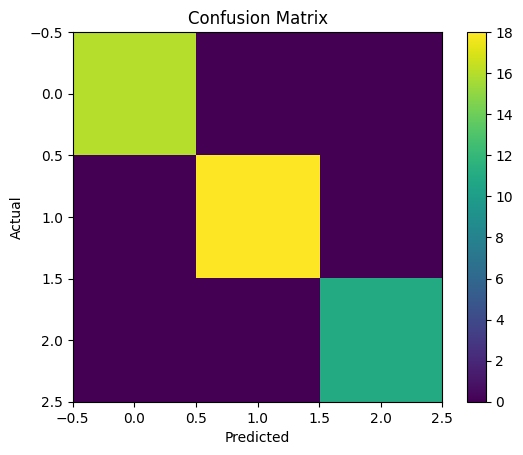

In [18]:
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Conclusion